In [1]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm

from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process

import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

/public/home/wuyy/miniconda3/envs/torch/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
import pickle

In [12]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
                test_label.append(hedge.detach().cpu().tolist())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        #test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label

In [13]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

In [14]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [15]:
model_dir = 'models/GM12878/'

model1 = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model1.to(device)

if model_dir:
    model1.load_state_dict(torch.load(model_dir+"model_epoch_7"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator1 = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator1.to(device)

if model_dir:
    Aggregator1.load_state_dict(torch.load(model_dir+"Aggregator_epoch_7"))

In [16]:
model_dir = 'models/K562/'

model2 = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model2.to(device)

if model_dir:
    model2.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator2 = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator2.to(device)

if model_dir:
    Aggregator2.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [17]:
model_dir = 'models/all/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [18]:
with open("chrom_data/GM12878/chr22_sliding_data","rb") as f:
        sliding_data1 = pickle.load(f)
        
with open("chrom_data/K562/chr22_sliding_data","rb") as f:
        sliding_data2 = pickle.load(f)

In [19]:
import pandas as pd

gene_annotation = pd.read_pickle('chrom_data/annotation/chr22_bins_gene_id.pkl')

In [20]:
with open("/public/home/wuyy/GM12878_hg38/chrom_state/chr22_5000_word","rb") as f:
    gm_state = pickle.load(f)

for i in range(len(gm_state),len(gene_annotation)):
    gm_state.append(['Quies'])
    
    
with open("/public/home/wuyy/K562_hg38/chrom_state/chr22_5000_word","rb") as f:
    k_state = pickle.load(f)

for i in range(len(k_state),len(gene_annotation)):
    k_state.append(['Quies'])

In [21]:
gene_annotation['gene_name'] = gene_annotation['gene_name'].str.replace(',', '', 1)
gene_annotation['gene_name'] = gene_annotation['gene_name'].str.replace(' ', '')

In [22]:
gene_annotation["GMstate"] = gm_state
gene_annotation["Kstate"] = k_state

In [23]:
import json

def get_gene_dict(data):
    symbol_standard_values = {}
    associations = data.get('associations', [])
    for association in associations:
        gene_symbol = association.get('gene', {}).get('symbol')
        standardized_value = association.get('standardizedValue')
        if gene_symbol is not None and standardized_value is not None:
            symbol_standard_values[gene_symbol] = standardized_value
            
    return symbol_standard_values

with open('chrom_data/GM12878_expression.txt', 'r') as file:
    data = json.load(file)

GM12878_dict = get_gene_dict(data)

with open('chrom_data/K562_expression.txt', 'r') as file:
    data = json.load(file)

K562_dict = get_gene_dict(data)


In [24]:
#gene_annotation['GM12878'] = gene_annotation['gene_name'].map(symbol_standard_values)

# 创建一个函数，将包含两个基因名的字符串拆分成列表，并分别映射到字典中的值
def map_gene_values(gene_names, gene_dict):
    genes = gene_names.split(',') # 按逗号+空格分割基因名字符串
    mapped_values = []
    for gene in genes:
        if gene in gene_dict.keys():
            mapped_values.append(gene_dict[gene])
    return mapped_values

# 应用这个函数到你的DataFrame中的 'gene_name' 列
gene_annotation['GM12878'] = gene_annotation['gene_name'].apply(map_gene_values, args=(GM12878_dict,))
gene_annotation['K562'] = gene_annotation['gene_name'].apply(map_gene_values, args=(K562_dict,))


In [25]:
g = gene_annotation[gene_annotation['GM12878'].apply(lambda x: len(x) > 0)]

with open("GM12878","rb") as f:
    annotate = pickle.load(f)

In [26]:
def counting(l):

    pos_label_counts = Counter(['a']) 
    neg_label_counts = Counter(['a']) 
    mix_label_counts = Counter(['a']) 

    p = 0
    n = 0
    m = 0

    for i in range(0,len(l)):
    
        df = sub_anno.iloc[l[i]]

        negative_count = sum(df['K562'].apply(lambda x: sum(1 for val in x if val < 0)))

        positive_count = sum(df['K562'].apply(lambda x: sum(1 for val in x if val > 0)))

        all_labels = [label for labels in df['Kstate'] for label in labels]

        label_counts = Counter(all_labels)
    
        if negative_count == 0 and positive_count > 0:
            pos_label_counts = pos_label_counts + label_counts
            p = p + len(l[i])
        
        elif negative_count > 0 and positive_count == 0:
            neg_label_counts = neg_label_counts + label_counts
            n = n + len(l[i])
        
        elif negative_count > 0 and positive_count > 0:
            mix_label_counts = mix_label_counts + label_counts
            m = m + len(l[i])
        
    return pos_label_counts, neg_label_counts, p, n

In [27]:
from collections import Counter

genome_labels = [label for labels in gene_annotation['Kstate'] for label in labels]
genome_counts = Counter(genome_labels)

s = sum(genome_counts.values())

genome_freq = {}
for k,v in genome_counts.items():
    genome_freq[k] = v/s


tgpos_label_counts, tgneg_label_counts, tgp, tgn = Counter(['a']), Counter(['a']), 0, 0
tbpos_label_counts, tbneg_label_counts, tbp, tbn = Counter(['a']), Counter(['a']), 0, 0


for i in range(0,len(sliding_data2)):

    anno = annotate["chr22"][i]

    sub_anno = gene_annotation[anno[0]+1:anno[-1]+2]
    sub_anno = sub_anno.reset_index()

    focus = sub_anno[sub_anno['K562'].apply(lambda x: len(x) > 0)].index.values.tolist()

    data1 = sliding_data2[i].to(device)

    test = []

    ran = focus

    for i in data1.hyper_edge:
        if len(set(i+ran)) < len(i) + len(ran):
            test.append(i)

    if len(test) <= 10:
        continue
    
    test_batchloader = load_val(test, 1000, device, label="pos")
    val_pred_pos22, total_label_pos22 = model_eval(data1, test_batchloader, model, Aggregator)
    
    good = []
    good_p = []
    bad = []
    bad_p = []

    for i, j in enumerate(val_pred_pos22):
        if j > 0.7:
            good.append(total_label_pos22[i])
            good_p.append(j)
            
        if j < 0.3:
            bad.append(total_label_pos22[i])
            bad_p.append(j)    
        

    gpos_label_counts, gneg_label_counts, gp, gn = counting(good)
    bpos_label_counts, bneg_label_counts, bp, bn = counting(bad)
    
    tgpos_label_counts = tgpos_label_counts + gpos_label_counts
    tgneg_label_counts = tgneg_label_counts + gneg_label_counts
    tgp = tgp + gp
    tgn = tgn + gn
    
    tbpos_label_counts = tbpos_label_counts + bpos_label_counts
    tbneg_label_counts = tbneg_label_counts + bneg_label_counts
    tbp = tbp + bp 
    tbn = tbn + bn
    

In [28]:
ktgpos_label_counts = tgpos_label_counts
ktgneg_label_counts = tgneg_label_counts
ktgp = tgp
ktgn = tgn

ktbpos_label_counts = tbpos_label_counts
ktbneg_label_counts = tbneg_label_counts
ktbp = tbp
ktbn = tbn

kgenome_freq = genome_freq

In [29]:
gtgpos_label_counts = tgpos_label_counts
gtgneg_label_counts = tgneg_label_counts
gtgp = tgp
gtgn = tgn

gtbpos_label_counts = tbpos_label_counts
gtbneg_label_counts = tbneg_label_counts
gtbp = tbp
gtbn = tbn

ggenome_freq = genome_freq

In [30]:
tgpos_label_counts = ktgpos_label_counts + gtgpos_label_counts
tgneg_label_counts = ktgneg_label_counts + gtgneg_label_counts
tgp = ktgp + gtgp
tgn = ktgn + gtgn

tbpos_label_counts = ktbpos_label_counts + gtbpos_label_counts
tbneg_label_counts = ktbneg_label_counts + gtbneg_label_counts
tbp = ktbp + gtbp
tbn = ktbn + gtbn

#genome_freq = kgenome_freq + ggenome_freq

In [31]:
gpos_ratio = {}

for k, v in tgpos_label_counts.items():
    if k == 'a':
        continue
    gpos_ratio[k] = (v/tgp)/np.mean([ggenome_freq[k],kgenome_freq[k]])

gneg_ratio = {}

for k, v in tgneg_label_counts.items():
    if k == 'a':
        continue
    gneg_ratio[k] = (v/tgn)/np.mean([ggenome_freq[k],kgenome_freq[k]])#genome_freq[k]
    

In [32]:
bpos_ratio = {}

for k, v in tbpos_label_counts.items():
    if k == 'a':
        continue
    bpos_ratio[k] = (v/tbp)/np.mean([ggenome_freq[k],kgenome_freq[k]])#genome_freq[k]

bneg_ratio = {}

for k, v in tbneg_label_counts.items():
    if k == 'a':
        continue
    bneg_ratio[k] = (v/tbn)/np.mean([ggenome_freq[k],kgenome_freq[k]])#genome_freq[k]
    

In [33]:
fgpos_ratio = {}

for k,v in gpos_ratio.items():
    fgpos_ratio[k] = v/sum(gpos_ratio.values())

In [34]:
fbpos_ratio = {}

for k,v in bpos_ratio.items():
    fbpos_ratio[k] = v/sum(bpos_ratio.values())

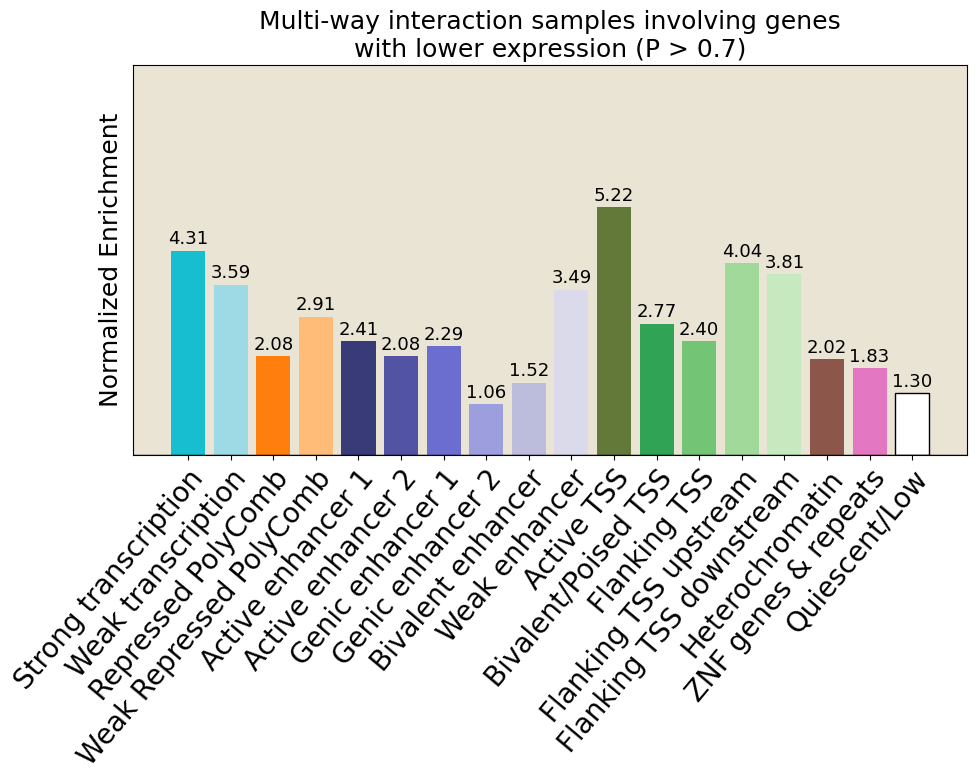

In [35]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})

# 提供的颜色映射
cmap = plt.cm.get_cmap('tab20')
cmap2 = plt.cm.get_cmap('tab20b')
cmap3 = plt.cm.get_cmap('tab20c')
label_colors = {
    'Strong transcription': cmap.colors[18], 
    'Weak transcription': cmap.colors[19], 
    'Repressed PolyComb': cmap.colors[2], 
    'Weak Repressed PolyComb': cmap.colors[3], 
    'Active enhancer 1': cmap2.colors[0],
    'Active enhancer 2': cmap2.colors[1],
    'Genic enhancer 1': cmap2.colors[2],
    'Genic enhancer 2': cmap2.colors[3],
    'Bivalent enhancer': cmap3.colors[14],
    'Weak enhancer': cmap3.colors[15],
    'Active TSS': cmap2.colors[4],
    'Bivalent/Poised TSS': cmap3.colors[8],
    'Flanking TSS': cmap3.colors[9],
    'Flanking TSS upstream': cmap3.colors[10],
    'Flanking TSS downstream': cmap3.colors[11],
    'Heterochromatin': cmap.colors[10],
    'ZNF genes & repeats': cmap.colors[12],
    'Quiescent/Low':'white'
}

label_label = {
    'Strong transcription': 'Tx', 
    'Weak transcription': 'TxWk', 
    'Repressed PolyComb': 'ReprPC', 
    'Weak Repressed PolyComb': 'ReprPCWk', 
    'Active enhancer 1': 'EnhA1',
    'Active enhancer 2': 'EnhA2',
    'Genic enhancer 1': 'EnhG1',
    'Genic enhancer 2': 'EnhG2',
    'Bivalent enhancer': 'EnhBiv',
    'Weak enhancer': 'EnhWk',
    'Active TSS': 'TssA',
    'Bivalent/Poised TSS': 'TssBiv',
    'Flanking TSS': 'TssFlnk',
    'Flanking TSS upstream': 'TssFlnkU',
    'Flanking TSS downstream': 'TssFlnkD',
    'Heterochromatin': 'Het',
    'ZNF genes & repeats': 'ZNF/Rpts',
    'Quiescent/Low':'Quies'
}

# 提供的柱状图数据
data1 = gpos_ratio

# 提取颜色和高度
colors = list(label_colors.values())
heights_up = [data1[label_label[label]] for label in label_colors.keys()]

# data2 = bneg_ratio
# heights_down = [data2[label_label[label]]*-1 for label in label_colors.keys()]


# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 8))
bars_up = ax.bar(label_colors.keys(), heights_up, color=colors)
last_bar_up = ax.bar(list(label_colors.keys())[-1], heights_up[-1], color='white', edgecolor='black')

# bars_down = ax.bar(label_colors.keys(), heights_down, color=colors)
# last_bar_down = ax.bar(list(label_colors.keys())[-1], heights_down[-1], color='white', edgecolor='black')



# 设置图例
#ax.legend(bars, label_colors.keys(), loc='upper left', bbox_to_anchor=(1, 1))

# 添加标签和标题
ax.set_ylabel('Normalized Enrichment', fontsize=18)
ax.set_title('Multi-way interaction samples involving genes\nwith lower expression (P > 0.7)', fontsize=18)

# 添加数据标签
for bar, height in zip(bars_up, heights_up):
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', va='bottom')

# for bar, height in zip(bars_down, heights_down):
#     ax.text(bar.get_x() + bar.get_width() / 2, height - 0.15, f'{height*-1:.2f}', ha='center', va='top')    
    

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)    

plt.xticks(rotation=50, fontsize=20, ha='right', va='top',  rotation_mode='anchor') 

plt.ylim(0, max(heights_up)+3)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_facecolor('#fff1cf') #""#e9e4d4") #

# 自动调整布局，以确保标签不重叠
plt.tight_layout()


# 保存图形
plt.savefig('expression_stat.png', dpi=300)

# 显示图形
plt.show()


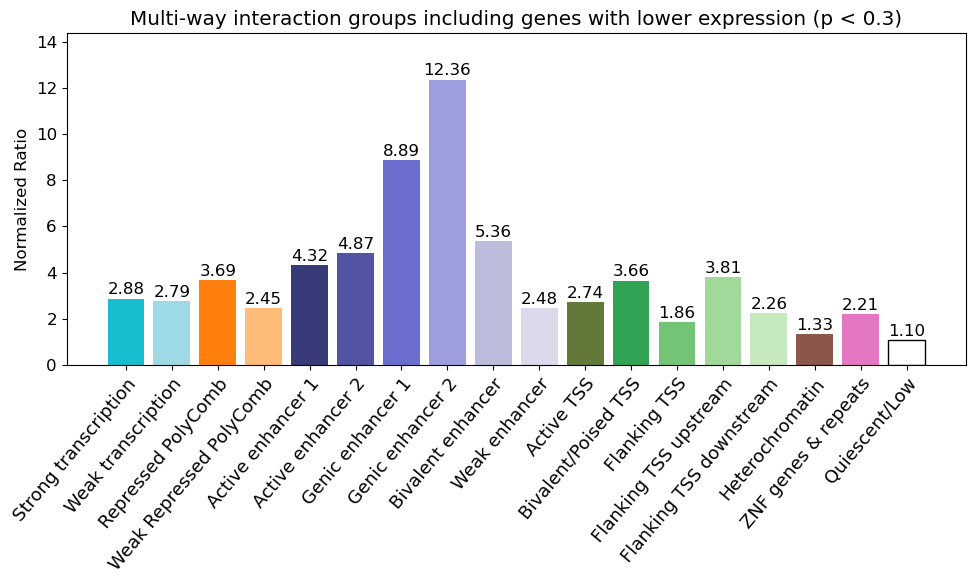

In [69]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# 提供的颜色映射
cmap = plt.cm.get_cmap('tab20')
cmap2 = plt.cm.get_cmap('tab20b')
cmap3 = plt.cm.get_cmap('tab20c')
label_colors = {
    'Strong transcription': cmap.colors[18], 
    'Weak transcription': cmap.colors[19], 
    'Repressed PolyComb': cmap.colors[2], 
    'Weak Repressed PolyComb': cmap.colors[3], 
    'Active enhancer 1': cmap2.colors[0],
    'Active enhancer 2': cmap2.colors[1],
    'Genic enhancer 1': cmap2.colors[2],
    'Genic enhancer 2': cmap2.colors[3],
    'Bivalent enhancer': cmap3.colors[14],
    'Weak enhancer': cmap3.colors[15],
    'Active TSS': cmap2.colors[4],
    'Bivalent/Poised TSS': cmap3.colors[8],
    'Flanking TSS': cmap3.colors[9],
    'Flanking TSS upstream': cmap3.colors[10],
    'Flanking TSS downstream': cmap3.colors[11],
    'Heterochromatin': cmap.colors[10],
    'ZNF genes & repeats': cmap.colors[12],
    'Quiescent/Low':'white'
}

label_label = {
    'Strong transcription': 'Tx', 
    'Weak transcription': 'TxWk', 
    'Repressed PolyComb': 'ReprPC', 
    'Weak Repressed PolyComb': 'ReprPCWk', 
    'Active enhancer 1': 'EnhA1',
    'Active enhancer 2': 'EnhA2',
    'Genic enhancer 1': 'EnhG1',
    'Genic enhancer 2': 'EnhG2',
    'Bivalent enhancer': 'EnhBiv',
    'Weak enhancer': 'EnhWk',
    'Active TSS': 'TssA',
    'Bivalent/Poised TSS': 'TssBiv',
    'Flanking TSS': 'TssFlnk',
    'Flanking TSS upstream': 'TssFlnkU',
    'Flanking TSS downstream': 'TssFlnkD',
    'Heterochromatin': 'Het',
    'ZNF genes & repeats': 'ZNF/Rpts',
    'Quiescent/Low':'Quies'
}

# 提供的柱状图数据
data = bpos_ratio

# 提取颜色和高度
colors = list(label_colors.values())
heights = [data[label_label[label]] for label in label_colors.keys()]

# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(label_colors.keys(), heights, color=colors)

last_bar = ax.bar(list(label_colors.keys())[-1], heights[-1], color='white', edgecolor='black')

# 设置图例
#ax.legend(bars, label_colors.keys(), loc='upper left', bbox_to_anchor=(1, 1))

# 添加标签和标题
ax.set_ylabel('Normalized Ratio')
ax.set_title('Multi-way interaction groups including genes with lower expression (p < 0.3)')

# 添加数据标签
for bar, height in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', va='bottom')


plt.xticks(rotation=50, fontsize=13, ha='right', va='top',  rotation_mode='anchor') 

plt.ylim(0, max(heights)+2)

# 自动调整布局，以确保标签不重叠
plt.tight_layout()

# 保存图形
#plt.savefig('enhancer_transcriptional_state_distribution.png')

# 显示图形
plt.show()
